# **Lightweight Machine Learning for Detecting DGA-Based  Botnet Communications**

Imports

In [ ]:
import kagglehub
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import math
from collections import Counter
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

Download Benign Domains

In [ ]:
cisco_path = kagglehub.dataset_download("adebayo/cisco-umbrella-list")
cisco_path += "/top-1m.csv"
print(cisco_path)

Using Colab cache for faster access to the 'cisco-umbrella-list' dataset.
/kaggle/input/cisco-umbrella-list/top-1m.csv


Download Malicious DGA Domains

In [ ]:
dga_path = kagglehub.dataset_download("gtkcyber/dga-dataset")
dga_path += "/dga_data.csv"
print(dga_path)

Using Colab cache for faster access to the 'dga-dataset' dataset.
/kaggle/input/dga-dataset/dga_data.csv


Load Datasets

In [ ]:
benign_domains = pd.read_csv(cisco_path, header=None)
benign_domains.columns = ["rank", "domain"]
benign_domains["label"] = 0

dga_domains = pd.read_csv(dga_path)
dga_domains["label"] = 1

print("Length of Benign Domain dataset:", len(benign_domains))
print("Length of DGA Domain dataset:", len(dga_domains))

benign_sample = benign_domains[["domain", "label"]]
dga_sample = dga_domains[["domain", "label"]]
df = pd.concat([benign_sample, dga_sample], ignore_index=True)

# Drop any rows with missing domains
print("Missing domains (benign):", benign_sample["domain"].isna().sum())
print("Missing domains (DGA):   ", dga_sample["domain"].isna().sum())
df = df.dropna(subset=["domain"]).reset_index(drop=True)
df["domain"] = df["domain"].astype(str).str.lower()

print("\nClass balance:")
print(df["label"].value_counts())
print(df["label"].value_counts(normalize=True).round(3))

Length of Benign Domain dataset: 1000000
Length of DGA Domain dataset: 160000
Missing domains (benign): 0
Missing domains (DGA):    2

Class balance:
label
0    1000000
1     159998
Name: count, dtype: int64
label
0    0.862
1    0.138
Name: proportion, dtype: float64


Extract Features

In [ ]:
def shannon_entropy(s):
    """Measures randomness of characters in a string. Higher = more random."""
    if not s:
        return 0.0
    counts = Counter(s)
    length = len(s)
    return -sum((c/length) * math.log2(c/length) for c in counts.values())

def vowel_ratio(s):
    if not s:
        return 0.0
    vowels = sum(1 for ch in s if ch in "aeiou")
    letters = sum(1 for ch in s if ch.isalpha())
    return vowels / letters if letters else 0.0

def digit_ratio(s):
    if not s:
        return 0.0
    return sum(1 for ch in s if ch.isdigit()) / len(s)

df["name"]       = df["domain"].str.split(".").str[0]
df["length"]     = df["name"].str.len()
df["entropy"]    = df["name"].apply(shannon_entropy)
df["vowel_ratio"] = df["name"].apply(vowel_ratio)
df["digit_ratio"] = df["name"].apply(digit_ratio)
df["unique_chars"] = df["name"].apply(lambda s: len(set(s)))

In [ ]:
print("\n--- Feature statistics by class ---")
summary = df.groupby("label")[["length", "entropy", "vowel_ratio", "digit_ratio", "unique_chars"]].agg(["mean", "std", "median"])
print(summary.round(3))

print("\n--- Random samples ---")
print("Benign:", df[df.label == 0]["domain"].sample(5, random_state=1).tolist())
print("DGA:   ", df[df.label == 1]["domain"].sample(5, random_state=1).tolist())


--- Feature statistics by class ---
       length               entropy               vowel_ratio                \
         mean    std median    mean    std median        mean    std median   
label                                                                         
0       8.547  6.434    7.0   2.306  1.012  2.522       0.273  0.218  0.308   
1      13.467  6.626   12.0   3.111  0.588  3.122       0.294  0.143  0.300   

      digit_ratio               unique_chars                
             mean    std median         mean    std median  
label                                                       
0           0.152  0.261    0.0        6.465  3.928    6.0  
1           0.057  0.145    0.0       10.040  4.082    9.0  

--- Random samples ---
Benign: ['m14.xshmbrw.in', 'cc.local', 'nesnpreprod.sb.blueconic.net', 'www.push.checkpoint.com', 'waws-prod-db3-003.vip.azurewebsites.windows.net']
DGA:    ['html', 'counterclicks', '1pxrb4s6c1yzi16lmeb1kkhcaw', 'dropboxusercontent', 'gr

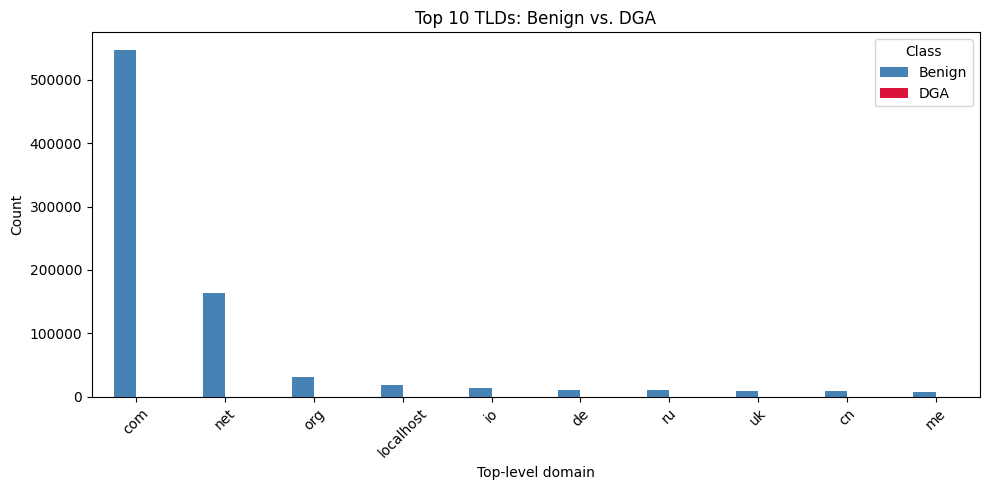

In [ ]:
df["tld"] = df["domain"].str.split(".").str[-1]
top_tlds = df["tld"].value_counts().head(10).index

tld_by_class = df[df.tld.isin(top_tlds)].groupby(["tld", "label"]).size().unstack(fill_value=0)
tld_by_class.columns = ["Benign", "DGA"]
tld_by_class = tld_by_class.loc[top_tlds]

fig, ax = plt.subplots(figsize=(10, 5))
tld_by_class.plot(kind="bar", ax=ax, color=["steelblue", "crimson"])
ax.set_xlabel("Top-level domain")
ax.set_ylabel("Count")
ax.set_title("Top 10 TLDs: Benign vs. DGA")
ax.legend(title="Class")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# Build a clean comparison table: Benign vs DGA side-by-side
features = ["length", "entropy", "vowel_ratio", "digit_ratio", "unique_chars"]

stats = df.groupby("label")[features].agg(["mean", "std", "median"])

# Reshape so features are rows and (class, stat) are columns
benign_stats = stats.loc[0].unstack(level=0)  # rows = stat, cols = feature
dga_stats    = stats.loc[1].unstack(level=0)

# Build a tidy summary dataframe
summary = pd.DataFrame({
    "Benign (mean)":   [df[df.label == 0][f].mean()   for f in features],
    "Benign (median)": [df[df.label == 0][f].median() for f in features],
    "Benign (std)":    [df[df.label == 0][f].std()    for f in features],
    "DGA (mean)":      [df[df.label == 1][f].mean()   for f in features],
    "DGA (median)":    [df[df.label == 1][f].median() for f in features],
    "DGA (std)":       [df[df.label == 1][f].std()    for f in features],
}, index=features)

# Add a difference column to highlight which features separate the classes
summary["Δ mean (DGA − Benign)"] = summary["DGA (mean)"] - summary["Benign (mean)"]

summary = summary.round(3)
print(summary.to_string())

              Benign (mean)  Benign (median)  Benign (std)  DGA (mean)  DGA (median)  DGA (std)  Δ mean (DGA − Benign)
length                8.547            7.000         6.434      13.467        12.000      6.626                  4.920
entropy               2.306            2.522         1.012       3.111         3.122      0.588                  0.805
vowel_ratio           0.273            0.308         0.218       0.294         0.300      0.143                  0.021
digit_ratio           0.152            0.000         0.261       0.057         0.000      0.145                 -0.095
unique_chars          6.465            6.000         3.928      10.040         9.000      4.082                  3.575


In [ ]:
# Styled version for notebook display
styled = (summary.style
    .background_gradient(subset=["Δ mean (DGA − Benign)"], cmap="RdBu_r")
    .format("{:.3f}")
    .set_caption("Feature Statistics by Class (0 = Benign, 1 = DGA)")
    .set_table_styles([
        {"selector": "caption", "props": [("font-size", "14px"), ("font-weight", "bold"), ("padding", "8px")]},
        {"selector": "th", "props": [("text-align", "center"), ("padding", "6px")]},
        {"selector": "td", "props": [("text-align", "right"), ("padding", "6px")]},
    ])
)
styled

,Benign (mean),Benign (median),Benign (std),DGA (mean),DGA (median),DGA (std),Δ mean (DGA − Benign)
length,8.547,7.000,6.434,13.467,12.000,6.626,4.920
entropy,2.306,2.522,1.012,3.111,3.122,0.588,0.805
vowel_ratio,0.273,0.308,0.218,0.294,0.300,0.143,0.021
digit_ratio,0.152,0.000,0.261,0.057,0.000,0.145,-0.095
unique_chars,6.465,6.000,3.928,10.040,9.000,4.082,3.575


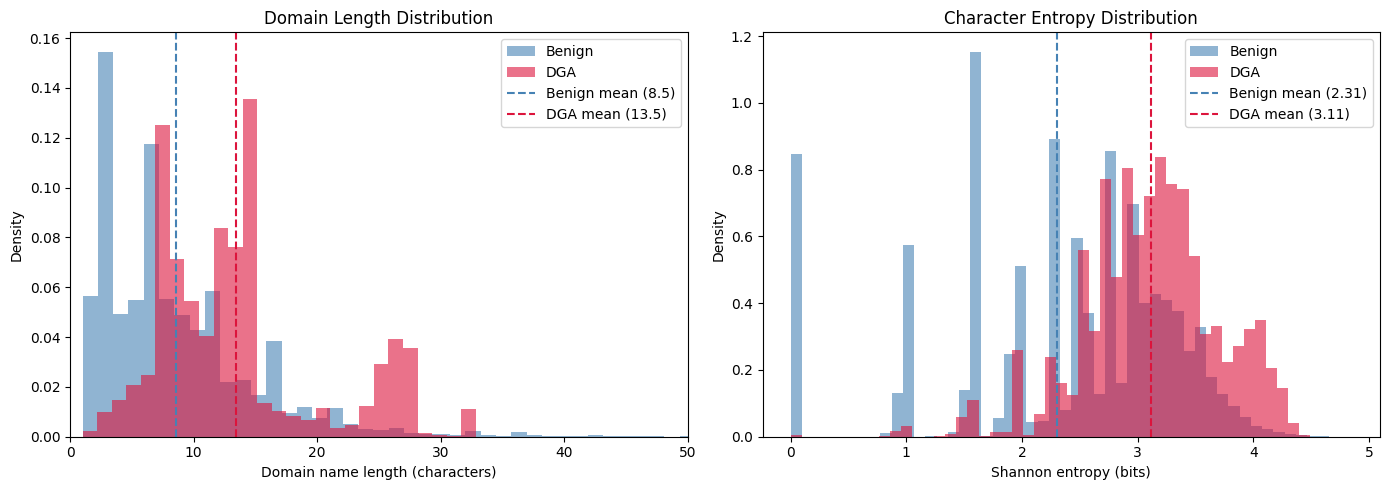

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Length ---
axes[0].hist(df[df.label == 0]["length"], bins=50, alpha=0.6,
             label="Benign", color="steelblue", density=True)
axes[0].hist(df[df.label == 1]["length"], bins=50, alpha=0.6,
             label="DGA", color="crimson", density=True)
axes[0].axvline(df[df.label == 0]["length"].mean(), color="steelblue",
                linestyle="--", linewidth=1.5, label=f"Benign mean ({df[df.label==0]['length'].mean():.1f})")
axes[0].axvline(df[df.label == 1]["length"].mean(), color="crimson",
                linestyle="--", linewidth=1.5, label=f"DGA mean ({df[df.label==1]['length'].mean():.1f})")
axes[0].set_xlabel("Domain name length (characters)")
axes[0].set_ylabel("Density")
axes[0].set_title("Domain Length Distribution")
axes[0].set_xlim(0, 50)
axes[0].legend()

# --- Entropy ---
axes[1].hist(df[df.label == 0]["entropy"], bins=50, alpha=0.6,
             label="Benign", color="steelblue", density=True)
axes[1].hist(df[df.label == 1]["entropy"], bins=50, alpha=0.6,
             label="DGA", color="crimson", density=True)
axes[1].axvline(df[df.label == 0]["entropy"].mean(), color="steelblue",
                linestyle="--", linewidth=1.5, label=f"Benign mean ({df[df.label==0]['entropy'].mean():.2f})")
axes[1].axvline(df[df.label == 1]["entropy"].mean(), color="crimson",
                linestyle="--", linewidth=1.5, label=f"DGA mean ({df[df.label==1]['entropy'].mean():.2f})")
axes[1].set_xlabel("Shannon entropy (bits)")
axes[1].set_ylabel("Density")
axes[1].set_title("Character Entropy Distribution")
axes[1].legend()

plt.tight_layout()
plt.show()

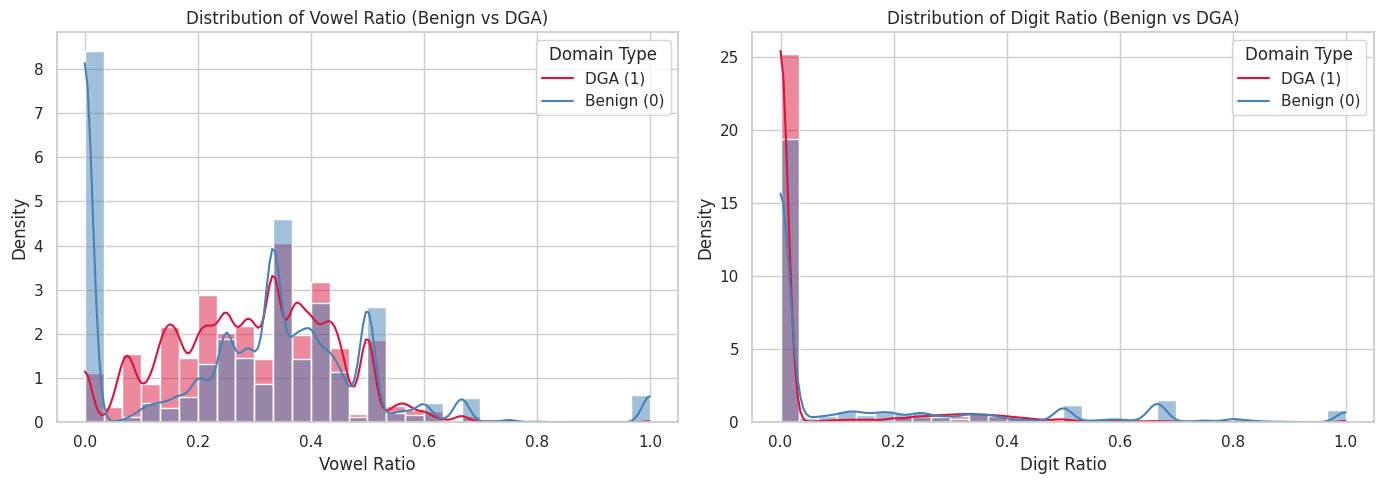

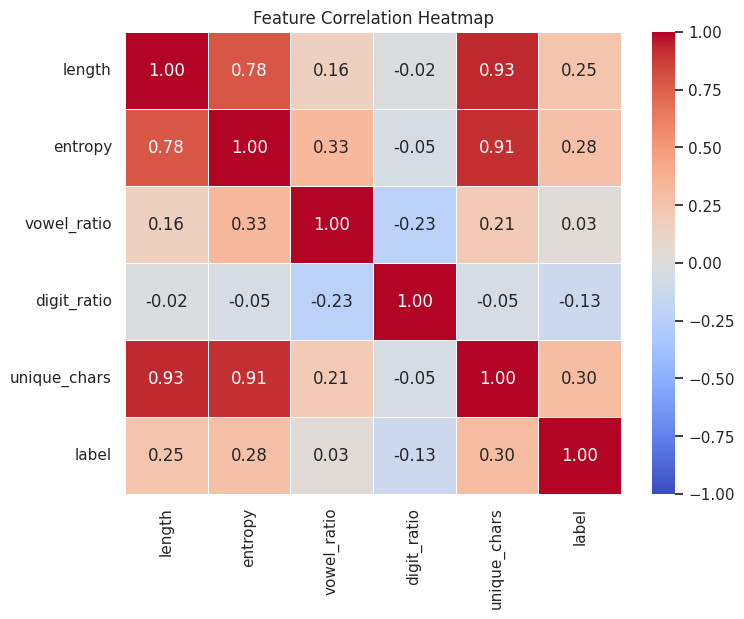

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# =============================
#Vowel & Digit Ratio
# ================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# plot the distribution og vowel_ratio
sns.histplot(data=df, x="vowel_ratio", hue="label", bins=30, kde=True,
             palette=["steelblue", "crimson"], ax=axes[0], stat="density", common_norm=False)
axes[0].set_title("Distribution of Vowel Ratio (Benign vs DGA)")
axes[0].set_xlabel("Vowel Ratio")
axes[0].set_ylabel("Density")
axes[0].legend(title="Domain Type", labels=["DGA (1)", "Benign (0)"])

# plot the distibution of digit_ratio
sns.histplot(data=df, x="digit_ratio", hue="label", bins=30, kde=True,
             palette=["steelblue", "crimson"], ax=axes[1], stat="density", common_norm=False)
axes[1].set_title("Distribution of Digit Ratio (Benign vs DGA)")
axes[1].set_xlabel("Digit Ratio")
axes[1].set_ylabel("Density")
axes[1].legend(title="Domain Type", labels=["DGA (1)", "Benign (0)"])

plt.tight_layout()
plt.show()

# =====================================
# Feature Correlation Heatmap
# ==================================
plt.figure(figsize=(8, 6))
# slect the characters
features = ['length', 'entropy', 'vowel_ratio', 'digit_ratio', 'unique_chars', 'label']
corr_matrix = df[features].corr()

# plot hotheap map
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title("Feature Correlation Heatmap")
plt.show()

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re
import nltk
from nltk.corpus import words

# Download NLTK's basic English vocabulary corpus
nltk.download('words')
english_words = set(words.words())

# Define the target column containing the domain names
TEXT_COL = 'name'

# Feature 1: Max Consecutive Consonants
# Natural languages rarely have more than 4 consecutive consonants,
# whereas DGA often generates random strings like "qxz".
def max_consecutive_consonants(text):
    if not isinstance(text, str): return 0
    consonants = re.findall(r'[^aeiou0-9\W_]+', text.lower())
    return max([len(c) for c in consonants]) if consonants else 0

# Feature 2: English Word Ratio
# Benign domains (e.g., facebook) often contain valid English words,
# while DGA-generated domains typically do not.
def english_word_ratio(text):
    if not isinstance(text, str) or len(text) == 0: return 0
    text_lower = text.lower()
    matched_length = 0
    # Search for valid English word substrings of length >= 3
    for i in range(len(text_lower)):
        for j in range(i + 3, len(text_lower) + 1):
            if text_lower[i:j] in english_words:
                matched_length = max(matched_length, j - i)
    return matched_length / len(text)

# Feature 3: Vowel-Consonant Transitions
# Natural language pronunciation rules dictate frequent alternations
# between vowels and consonants.
def vc_transitions(text):
    if not isinstance(text, str) or len(text) <= 1: return 0
    text_clean = re.sub(r'[^a-z]', '', text.lower())
    if len(text_clean) <= 1: return 0

    vowels = set('aeiou')
    transitions = sum(1 for i in range(1, len(text_clean))
                      if (text_clean[i] in vowels) != (text_clean[i-1] in vowels))
    return transitions / len(text_clean)

# Apply the engineered features to the DataFrame
df['max_cons_len'] = df[TEXT_COL].apply(max_consecutive_consonants)
df['eng_word_ratio'] = df[TEXT_COL].apply(english_word_ratio)
df['vc_transitions'] = df[TEXT_COL].apply(vc_transitions)

[nltk_data] Downloading package words to /root/nltk_data...
[nltk_data]   Package words is already up-to-date!


In [ ]:
import torch
from transformers import GPT2LMHeadModel, GPT2Tokenizer
from tqdm import tqdm

# ================= 1. Load the functions =================
print("Now loading GPT-2 model(LLM)...")
tokenizer = GPT2Tokenizer.from_pretrained('gpt2')
model = GPT2LMHeadModel.from_pretrained('gpt2')
model.eval()

device = 'cuda' if torch.cuda.is_available() else 'cpu'
model.to(device)

def get_llm_perplexity(text):
    if not isinstance(text, str) or len(text) == 0: return 0
    inputs = tokenizer(text, return_tensors='pt').to(device)
    with torch.no_grad():
        outputs = model(**inputs, labels=inputs['input_ids'])
        loss = outputs.loss
    return torch.exp(loss).item()

# ================= 2. caculating =================
print("Random slection...")
sample_size = min(10000, len(df)) # if possible, larger dataset can be used to extract a more accuarte results
df_sample = df.sample(n=sample_size, random_state=42).copy()

tqdm.pandas(desc="Caculating LLM-perplexing")

df_sample['llm_perplexity'] = df_sample['domain'].progress_apply(get_llm_perplexity)

print("Finsihed")

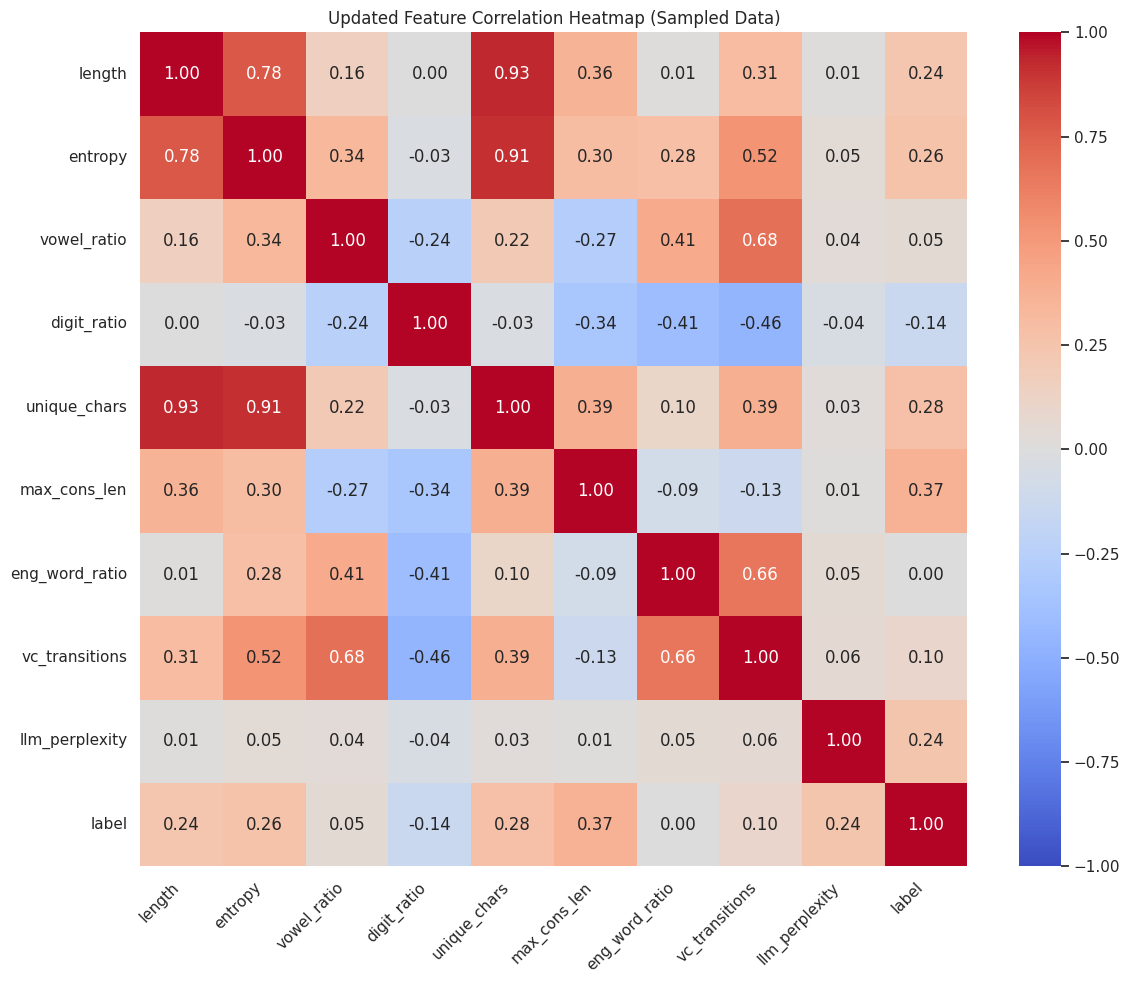

In [ ]:
# Add new features coupled with previos features
features_to_plot = [
    'length', 'entropy', 'vowel_ratio', 'digit_ratio', 'unique_chars',
    'max_cons_len', 'eng_word_ratio', 'vc_transitions', 'llm_perplexity', 'label'
]

existing_cols = [col for col in features_to_plot if col in df_sample.columns]
# caculating
corr_matrix = df_sample[existing_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Updated Feature Correlation Heatmap (Sampled Data)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()